<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SectorLeadershipModern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade yfinance

In [24]:
import seaborn as sns
import yfinance as yf
print(yf.__version__)
import pandas as pd
#import pandas_ta as ta
import numpy as np
from datetime import datetime
import time
import matplotlib.pyplot as plt


print("Libraries Installed!")

1.4.1
Libraries Installed!


## Define Sector and Benchmark

In [32]:
tickers = [
    'XLK','XLF','XLV','XLI','XLY', 'XBI', 'GBTC',
    'XLP','XLE','XLU','XLB','XLRE','SOXX', 'GBTC', 'GLD','SLV',
    'XLC','SPY'
]

prices = yf.download(
    tickers,
    start="2020-01-01",
    auto_adjust=True
)['Close']

weekly = prices.resample('W-FRI').last()

current_week_end = weekly.index[-1]
previous_week_end = weekly.index[-2]

# =============================
# 2. SCORE FUNCTION (FIXED RS + ACCEL)
# =============================
def calculate_score(data, as_of):

    df = data.loc[:as_of]

    sector = df.drop(columns="SPY")

    # -----------------------------
    # Relative Strength
    # -----------------------------
    rs = sector.div(df["SPY"], axis=0)

    # -----------------------------
    # RS Momentum (4-week change)
    # -----------------------------
    rs_momentum = rs.pct_change(4)

    # -----------------------------
    # RS Acceleration (change in momentum)
    # -----------------------------
    rs_accel = rs_momentum.diff(1)

    # -----------------------------
    # RS Slope (trend of RS)
    # -----------------------------
    rs_slope = (
        rs.rolling(4).mean().iloc[-1] -
        rs.rolling(4).mean().iloc[-4]
    )

    # -----------------------------
    # Latest snapshot
    # -----------------------------
    score = pd.DataFrame({
        "RS_Strength": rs.iloc[-1],
        "RS_Momentum": rs_momentum.iloc[-1],
        "RS_Accel": rs_accel.iloc[-1],
        "RS_Slope": rs_slope
    })

    # Composite rank score
    score["Total"] = score.rank(ascending=False).mean(axis=1)

    return score


# =============================
# 3. CURRENT / PREVIOUS SCORES
# =============================
current_score = calculate_score(weekly, current_week_end)
previous_score = calculate_score(weekly, previous_week_end)

# =============================
# 4. RANKS
# =============================
curr_rank = current_score["Total"].rank()
prev_rank = previous_score["Total"].rank()

# =============================
# 5. IMPACT (NOW USING ACCELERATION)
# =============================
impact = (prev_rank - curr_rank) * current_score["RS_Accel"].abs()

# =============================
# 6. ROTATION TABLE
# =============================
df = pd.DataFrame({
    "Prev Rank": prev_rank,
    "Curr Rank": curr_rank,
    "Rank Change": prev_rank - curr_rank,
    "RS_Strength": current_score["RS_Strength"],
    "RS_Momentum": current_score["RS_Momentum"],
    "RS_Accel": current_score["RS_Accel"],
    "Impact": impact
})

df = df.sort_values("Impact", ascending=False)

# =============================
# 7. TOP 5 ROTATION RATE
# =============================
N = 5

top_now = set(current_score.sort_values("Total").head(N).index)
top_prev = set(previous_score.sort_values("Total").head(N).index)

rotating_in = top_now - top_prev
rotating_out = top_prev - top_now

rotation_rate = len(rotating_in) / N

# =============================
# 8. REGIME CLASSIFICATION
# =============================
if rotation_rate == 0:
    regime = "Stable Leadership"
elif rotation_rate <= 0.2:
    regime = "Low Rotation"
elif rotation_rate <= 0.4:
    regime = "Mild Rotation"
elif rotation_rate <= 0.6:
    regime = "Moderate Rotation"
else:
    regime = "High Rotation"

# =============================
# 9. FLOW LABELS
# =============================
def flow(x):
    if x >= 3:
        return "Strong Inflow 🚀"
    elif x >= 1:
        return "Mild Inflow 📈"
    elif x <= -3:
        return "Strong Outflow 🔻"
    elif x <= -1:
        return "Mild Outflow 📉"
    else:
        return "Neutral"

df["Flow"] = df["Rank Change"].apply(flow)

# =============================
# 10. OUTPUT
# =============================
print("\n==============================")
print("SECTOR ROTATION ENGINE (v2)")
print("==============================")

print(f"Current Week  : {current_week_end.date()}")
print(f"Previous Week : {previous_week_end.date()}")
print(f"Rotation Rate : {rotation_rate:.0%}")
print(f"Regime        : {regime}")

print("\nRotating IN:")
print(rotating_in if rotating_in else "None")

print("\nRotating OUT:")
print(rotating_out if rotating_out else "None")

print("\n==============================")
print("IMPACT TABLE")
print("==============================")

df

[*********************100%***********************]  17 of 17 completed


SECTOR ROTATION ENGINE (v2)
Current Week  : 2026-06-26
Previous Week : 2026-06-19
Rotation Rate : 20%
Regime        : Low Rotation

Rotating IN:
{'XLF'}

Rotating OUT:
{'XLK'}

IMPACT TABLE


,Prev Rank,Curr Rank,Rank Change,RS_Strength,RS_Momentum,RS_Accel,Impact,Flow
Ticker,,,,,,,,
XLE,16.0,7.0,9.0,0.073823,-0.003303,0.096498,0.868481,Strong Inflow 🚀
XLP,11.0,6.0,5.0,0.114427,0.048586,0.070242,0.351209,Strong Inflow 🚀
XLRE,14.5,10.0,4.5,0.060643,0.049291,0.068975,0.310390,Strong Inflow 🚀
XLU,12.0,8.5,3.5,0.062455,0.067658,0.084654,0.296290,Strong Inflow 🚀
XLV,5.0,2.0,3.0,0.212547,0.077685,0.084980,0.254939,Strong Inflow 🚀
XBI,3.0,1.0,2.0,0.206158,0.139118,0.074621,0.149243,Mild Inflow 📈
XLF,6.0,5.0,1.0,0.073020,0.071906,0.044689,0.044689,Mild Inflow 📈
XLI,4.0,3.5,0.5,0.249956,0.092039,0.043082,0.021541,Neutral
XLC,10.0,13.5,-3.5,0.144261,-0.056673,-0.000791,-0.002770,Strong Outflow 🔻


In [33]:
# =============================
# SECTOR SIGNAL CLASSIFICATION
# =============================

def sector_signal(row, rank_series):

    rank = rank_series[row.name]
    accel = row["RS_Accel"]
    rank_change = row["Rank Change"]

    # Top, mid, bottom segmentation
    if rank <= 5:
        tier = "top"
    elif rank <= 10:
        tier = "mid"
    else:
        tier = "weak"

    # -----------------------------
    # BUY CONDITIONS
    # -----------------------------
    if tier == "top" and accel > 0 and rank_change > 0:
        return "BUY 🟢"

    if tier == "top" and accel > 0:
        return "BUY 🟢 (early)"

    # -----------------------------
    # WATCH CONDITIONS
    # -----------------------------
    if tier == "mid" and accel >= 0:
        return "WATCH 🟡 (improving)"

    if tier == "top" and accel <= 0:
        return "WATCH 🟡 (late cycle)"

    if tier == "mid" and rank_change > 0:
        return "WATCH 🟡 (building)"

    # -----------------------------
    # AVOID CONDITIONS
    # -----------------------------
    if tier == "weak" and accel < 0:
        return "AVOID 🔴"

    if rank_change < 0 and accel < 0:
        return "AVOID 🔴 (distribution)"

    return "WATCH 🟡"

In [35]:
df["Signal"] = df.apply(
    sector_signal,
    axis=1,
    rank_series=curr_rank
)

final_view = df.sort_values(
    ["Signal", "Impact"],
    ascending=[True, False]
)

print("\n==============================")
print("SECTOR SIGNAL DASHBOARD")
print("==============================")

final_view


SECTOR SIGNAL DASHBOARD


,Prev Rank,Curr Rank,Rank Change,RS_Strength,RS_Momentum,RS_Accel,Impact,Flow,Signal
Ticker,,,,,,,,,
XLC,10.0,13.5,-3.5,0.144261,-0.056673,-0.000791,-0.002770,Strong Outflow 🔻,AVOID 🔴
XLY,9.0,12.0,-3.0,0.154635,-0.032759,-0.011840,-0.035520,Strong Outflow 🔻,AVOID 🔴
GLD,8.0,13.5,-5.5,0.504121,-0.088086,-0.019787,-0.108830,Strong Outflow 🔻,AVOID 🔴
SLV,14.5,16.0,-1.5,0.071569,-0.209700,-0.076723,-0.115084,Mild Outflow 📉,AVOID 🔴
XLK,2.0,8.5,-6.5,0.251570,-0.005104,-0.062074,-0.403481,Strong Outflow 🔻,AVOID 🔴 (distribution)
XLV,5.0,2.0,3.0,0.212547,0.077685,0.084980,0.254939,Strong Inflow 🚀,BUY 🟢
XBI,3.0,1.0,2.0,0.206158,0.139118,0.074621,0.149243,Mild Inflow 📈,BUY 🟢
XLF,6.0,5.0,1.0,0.073020,0.071906,0.044689,0.044689,Mild Inflow 📈,BUY 🟢
XLI,4.0,3.5,0.5,0.249956,0.092039,0.043082,0.021541,Neutral,BUY 🟢


## Step 6: Detect Rotation

In [18]:
# -----------------------------
# TOP 5 SECTOR ROTATION LOGIC
# -----------------------------
N = 5

top_now = set(current_score.head(N).index)
top_prev = set(previous_score.head(N).index)

# New leadership entering top 5
rotating_in = top_now - top_prev

# Old leadership leaving top 5
rotating_out = top_prev - top_now

# Rotation rate
rotation_rate = len(rotating_in) / N

# -----------------------------
# REGIME CLASSIFICATION
# -----------------------------
if rotation_rate == 0.0:
    regime = "Stable Leadership"
elif rotation_rate <= 0.2:
    regime = "Low Rotation (Trend Continuation)"
elif rotation_rate <= 0.4:
    regime = "Mild Rotation (Early Capital Shift)"
elif rotation_rate <= 0.6:
    regime = "Moderate Rotation (Regime Transition)"
else:
    regime = "High Rotation (Aggressive Regime Change)"

# -----------------------------
# OUTPUT SUMMARY TABLES
# -----------------------------
print("\n==============================")
print("SECTOR ROTATION SUMMARY")
print("==============================")
print(f"Rotation Rate: {rotation_rate:.0%}")
print(f"Regime       : {regime}")

print("\nTop 5 Previous Leaders:")
print(sorted(top_prev))

print("\nTop 5 Current Leaders:")
print(sorted(top_now))

print("\nRotating IN (New Leaders):")
print(sorted(rotating_in) if rotating_in else "None")

print("\nRotating OUT (Fading Leaders):")
print(sorted(rotating_out) if rotating_out else "None")


SECTOR ROTATION SUMMARY
Rotation Rate: 20%
Regime       : Low Rotation (Trend Continuation)

Top 5 Previous Leaders:
['SOXX', 'XBI', 'XLF', 'XLI', 'XLK']

Top 5 Current Leaders:
['SOXX', 'XBI', 'XLF', 'XLI', 'XLV']

Rotating IN (New Leaders):
['XLV']

Rotating OUT (Fading Leaders):
['XLK']


# 🧭 Sector Rotation Heatmap

In [23]:
# -----------------------------
# RANKS (lower is better)
# -----------------------------
current_rank = current_score['Total'].rank()
previous_rank = previous_score['Total'].rank()

# -----------------------------
# COMBINE INTO DATAFRAME
# -----------------------------
heatmap_df = pd.DataFrame({
    "Previous Rank": previous_rank,
    "Current Rank": current_rank
})

# Rank change (positive = improving)
heatmap_df["Rank Change"] = heatmap_df["Previous Rank"] - heatmap_df["Current Rank"]

def classify_change(x):
    if x >= 3:
        return "Strong Inflow 🚀"
    elif x >= 1:
        return "Mild Inflow 📈"
    elif x <= -3:
        return "Strong Outflow 🔻"
    elif x <= -1:
        return "Mild Outflow 📉"
    else:
        return "Neutral"

heatmap_df["Flow"] = heatmap_df["Rank Change"].apply(classify_change)

def color_map(val):
    if val >= 3:
        return "background-color: darkgreen; color: white"
    elif val >= 1:
        return "background-color: lightgreen"
    elif val <= -3:
        return "background-color: darkred; color: white"
    elif val <= -1:
        return "background-color: lightcoral"
    else:
        return "background-color: lightgrey"

styled = heatmap_df.style.applymap(
    color_map,
    subset=["Rank Change"]
)

styled

/tmp/ipykernel_1630/2662092769.py:44: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = heatmap_df.style.applymap(


,Previous Rank,Current Rank,Rank Change,Flow
Ticker,,,,
GBTC,15.500000,14.000000,1.500000,Mild Inflow 📈
GLD,15.500000,15.000000,0.500000,Neutral
SLV,14.000000,16.000000,-2.000000,Mild Outflow 📉
SOXX,1.000000,1.000000,0.000000,Neutral
XBI,3.000000,2.000000,1.000000,Mild Inflow 📈
XLB,7.000000,8.000000,-1.000000,Mild Outflow 📉
XLC,12.000000,13.000000,-1.000000,Mild Outflow 📉
XLE,13.000000,12.000000,1.000000,Mild Inflow 📈
XLF,5.000000,5.000000,0.000000,Neutral


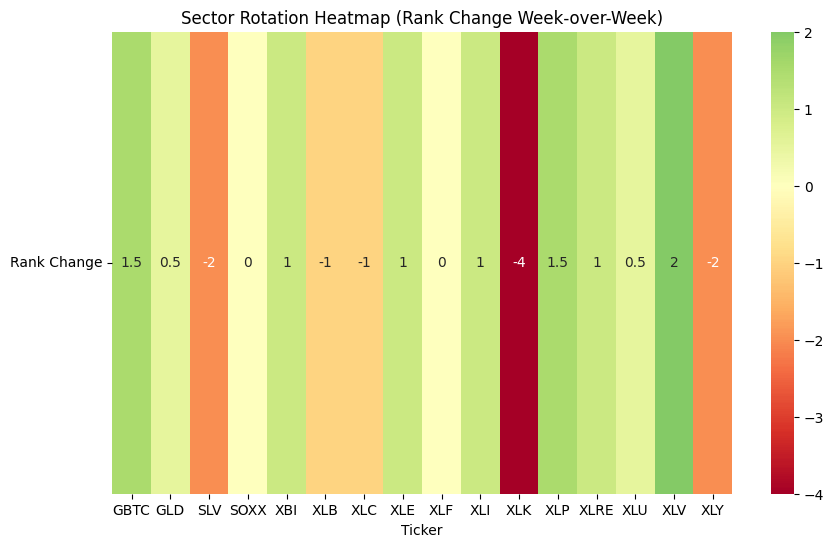

In [25]:


plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_df[["Rank Change"]].T,
    annot=True,
    cmap="RdYlGn",
    center=0,
    cbar=True
)

plt.title("Sector Rotation Heatmap (Rank Change Week-over-Week)")
plt.yticks(rotation=0)
plt.show()